<a href="https://colab.research.google.com/github/Rushikesh042/VLM-Dental-Classification/blob/main/ToothFairy2_Dataset_Pre_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ToothFairy2 DATASET PRE-PROCESSING

## 1. PROJECT PATHS

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/Teeth_Segmentation_Classification')
# ----------------------------------------------
TOOTHFAIRY_RAW = PROJECT_ROOT / 'ToothFairy2'

WORK_DIR     = Path('/content/work')
PREPROC_ROOT = PROJECT_ROOT / 'Preprocessed_Dataset'
TF2_PREPROC  = PREPROC_ROOT / 'ToothFairy2'
LOG_DIR = PROJECT_ROOT / 'Logs'

for d in [
    WORK_DIR,
    TF2_PREPROC,
    LOG_DIR,
    TF2_PREPROC / 'images',
    TF2_PREPROC / 'labels',
]:
    d.mkdir(exist_ok=True, parents=True)

print(f"Project root:  {PROJECT_ROOT}")
print(f"  TF2 Raw:     {TOOTHFAIRY_RAW}  {'OK' if TOOTHFAIRY_RAW.exists() else 'MISSING'}")
print(f"  Preproc:     {PREPROC_ROOT}")
print(f"  Logs:        {LOG_DIR}")

Project root:  /content/drive/MyDrive/Teeth_Segmentation_Classification
  TF2 Raw:     /content/drive/MyDrive/Teeth_Segmentation_Classification/ToothFairy2  OK
  Preproc:     /content/drive/MyDrive/Teeth_Segmentation_Classification/Preprocessed_Dataset
  Logs:        /content/drive/MyDrive/Teeth_Segmentation_Classification/Logs


## 2. INSTALL DEPENDENCIES

In [ ]:
!pip install -q SimpleITK nibabel monai einops tqdm
print("Dependencies installed.")

Dependencies installed.


## 3. IMPORTS, LOGGING, REPRODUCIBILITY

In [ ]:
import subprocess
import os, sys, json, gc, hashlib, logging, re
from dataclasses import dataclass, field, asdict
from typing import Optional, Tuple, Dict, List, Any
from scipy.ndimage import binary_dilation

import numpy as np
import pandas as pd
import SimpleITK as sitk
from tqdm.auto import tqdm

SEED = 42
np.random.seed(SEED)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%H:%M:%S',
)
log = logging.getLogger('preproc')

print(f"NumPy:     {np.__version__}")
print(f"pandas:    {pd.__version__}")
print(f"SimpleITK: {sitk.Version_VersionString()}")

NumPy:     2.0.2
pandas:    2.2.2
SimpleITK: 2.5.5


## 4. PREPROCESSING CONFIG


In [ ]:
@dataclass
class PreprocConfig:
    # --- Geometric ---
    target_spacing: Tuple[float, float, float] = (0.4, 0.4, 0.4)  # mm, isotropic

    # --- Intensity normalization ---
    use_percentile_clip: bool = True  # CBCT is not in HU; percentile clip is required
    clip_percentiles: Tuple[float, float] = (0.5, 99.5)
    fixed_clip_range: Tuple[float, float] = (-1000.0, 3000.0)

    # --- MMDental label policy ---
    drop_normal_class: bool = True  # if True, patients with no pathology label are dropped
    pathology_classes: Tuple[str, ...] = ('ENDO', 'PERIO', 'DEV_POS', 'CARIES_STRUCT')

    # --- Pipeline behavior ---
    skip_existing: bool = True               # idempotent re-runs
    save_dtype_image: str = 'float32'
    save_dtype_label: str = 'uint8'
    text_max_chars: int = 800                # truncate clinical history before tokenizer

PREPROC = PreprocConfig()
print("Preprocessing config:")
for k, v in asdict(PREPROC).items():
    print(f"  {k}: {v}")

Preprocessing config:
  target_spacing: (0.4, 0.4, 0.4)
  use_percentile_clip: True
  clip_percentiles: (0.5, 99.5)
  fixed_clip_range: (-1000.0, 3000.0)
  drop_normal_class: True
  pathology_classes: ('ENDO', 'PERIO', 'DEV_POS', 'CARIES_STRUCT')
  skip_existing: True
  save_dtype_image: float32
  save_dtype_label: uint8
  text_max_chars: 800


## 5. VOLUMETRIC I/O, RESAMPLING, NORMALIZATION

In [ ]:
def load_volume(path: Path) -> Dict[str, Any]:
    """Load .mha or .nii.gz via SimpleITK, canonicalize orientation to LPS.
    Returns array + metadata. LPS = standard radiological orientation, so left/right
    sides are consistent across all volumes — required for per-tooth FDI labels."""
    img = sitk.ReadImage(str(path))
    img = sitk.DICOMOrient(img, 'LPS')   # canonical orientation
    arr = sitk.GetArrayFromImage(img)    # [D, H, W]
    return {
        'array':     arr,
        'spacing':   tuple(img.GetSpacing()),
        'origin':    tuple(img.GetOrigin()),
        'direction': tuple(img.GetDirection()),
        'dtype':     str(arr.dtype),
        'shape':     tuple(arr.shape),
    }


def resample_volume(
    arr: np.ndarray,
    src_spacing: Tuple[float, float, float],
    target_spacing: Tuple[float, float, float],
    is_label: bool = False,
    src_origin: Optional[Tuple[float, ...]] = None,
    src_direction: Optional[Tuple[float, ...]] = None,
) -> np.ndarray:
    """Resample a 3D volume to target isotropic spacing.

    Args:
        arr: numpy [D, H, W] (z, y, x) array.
        src_spacing: source (sx, sy, sz) in SITK order.
        target_spacing: target (sx, sy, sz).
        is_label: nearest-neighbor if True (preserves discrete values), else linear.
        src_origin, src_direction: optional, preserves physical alignment.
    """
    img = sitk.GetImageFromArray(arr)
    img.SetSpacing(tuple(float(s) for s in src_spacing))
    if src_origin is not None:
        img.SetOrigin(tuple(float(v) for v in src_origin))
    if src_direction is not None:
        img.SetDirection(tuple(float(v) for v in src_direction))

    src_size = img.GetSize()  # SITK (W, H, D)
    new_size = [
        max(1, int(round(src_size[i] * src_spacing[i] / target_spacing[i])))
        for i in range(3)
    ]

    interp = sitk.sitkNearestNeighbor if is_label else sitk.sitkLinear
    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(target_spacing)
    resampler.SetSize(new_size)
    resampler.SetOutputOrigin(img.GetOrigin())
    resampler.SetOutputDirection(img.GetDirection())
    resampler.SetInterpolator(interp)
    resampler.SetDefaultPixelValue(0)

    return sitk.GetArrayFromImage(resampler.Execute(img))


def normalize_intensity(
    arr: np.ndarray,
    use_percentile_clip: bool,
    fixed_clip_range: Tuple[float, float],
    clip_percentiles: Tuple[float, float],
    eps: float = 1e-6,
    air_percentile: float = 5.0,
) -> np.ndarray:
    """Per-volume clip + tissue-masked z-score.

    Air is excluded from mean/std so the normalization is centered on tissue,
    not on the empty volume around the patient. Critical for CBCT where FOV
    often extends well beyond the head.
    """
    arr = arr.astype(np.float32, copy=True)
    if use_percentile_clip:
        lo, hi = np.percentile(arr, clip_percentiles)
    else:
        lo, hi = fixed_clip_range
    if hi <= lo:
        return np.zeros_like(arr)
    np.clip(arr, lo, hi, out=arr)

    # Tissue mask: anything above the lowest 5% counts as tissue, not air
    air_thr = np.percentile(arr, air_percentile)
    fg = arr > air_thr
    if fg.sum() < 100:
        return np.zeros_like(arr)
    mean = arr[fg].mean()
    std  = arr[fg].std() + eps
    return (arr - mean) / std


def crop_or_pad_to(
    arr: np.ndarray,
    target_shape: Tuple[int, int, int],
    pad_value: float = 0.0,
) -> np.ndarray:
    """Center-crop or pad to (D, H, W). Used by training datasets."""
    D, H, W = arr.shape
    tD, tH, tW = target_shape
    pad_d = max(0, tD - D)
    pad_h = max(0, tH - H)
    pad_w = max(0, tW - W)
    if pad_d or pad_h or pad_w:
        arr = np.pad(
            arr,
            [(pad_d // 2, pad_d - pad_d // 2),
             (pad_h // 2, pad_h - pad_h // 2),
             (pad_w // 2, pad_w - pad_w // 2)],
            mode='constant', constant_values=pad_value,
        )
        D, H, W = arr.shape
    sd = (D - tD) // 2
    sh = (H - tH) // 2
    sw = (W - tW) // 2
    return arr[sd:sd + tD, sh:sh + tH, sw:sw + tW]


def md5_of_file(path: Path, chunk: int = 1 << 20) -> str:
    """Hex MD5 — use in manifests for provenance/deduplication checks."""
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for buf in iter(lambda: f.read(chunk), b''):
            h.update(buf)
    return h.hexdigest()


print("I/O + resampling + normalization utilities loaded.")

I/O + resampling + normalization utilities loaded.


## 6. ToothFairy2 LABEL MAPPING


In [ ]:
TF2_NUM_SEG_CLASSES = 4
TF2_CLASS_NAMES = ('background', 'teeth', 'jaws', 'IAC')

TF2_LABEL_MAP: Dict[int, int] = {0: 0}            # background
TF2_LABEL_MAP[1] = 2                              # lower jawbone -> jaws
TF2_LABEL_MAP[2] = 2                              # upper jawbone -> jaws
TF2_LABEL_MAP[3] = 3                              # left IAC      -> IAC
TF2_LABEL_MAP[4] = 3                              # right IAC     -> IAC
for src in (5, 6, 7, 8, 9, 10, 40):
    TF2_LABEL_MAP[src] = 0
for fdi in (11, 12, 13, 14, 15, 16, 17, 18,       # FDI permanent dentition -> teeth
            21, 22, 23, 24, 25, 26, 27, 28,
            31, 32, 33, 34, 35, 36, 37, 38,
            41, 42, 43, 44, 45, 46, 47, 48):
    TF2_LABEL_MAP[fdi] = 1


def build_label_lut(label_map: Dict[int, int], lut_size: int = 256) -> np.ndarray:
    """Build uint8 LUT where lut[src] = dst. Unmapped indices stay 0."""
    lut = np.zeros(lut_size, dtype=np.uint8)
    for src, dst in label_map.items():
        if not (0 <= src < lut_size):
            raise ValueError(f"Label {src} outside LUT range [0, {lut_size})")
        lut[src] = dst
    return lut


def remap_labels(label_volume: np.ndarray, lut: np.ndarray) -> np.ndarray:
    """Apply LUT. Values outside [0, len(lut)) are mapped to 0 (background)."""
    n = len(lut)
    lv = label_volume.astype(np.int64, copy=False)
    safe = np.where((lv >= 0) & (lv < n), lv, 0)
    return lut[safe]


def verify_tf2_label_map(dataset_json_path: Path) -> List[str]:
    """Cross-check the LUT against ToothFairy2's dataset.json. Returns warnings."""
    if not dataset_json_path.exists():
        return [f"dataset.json not found at {dataset_json_path}"]
    with open(dataset_json_path) as f:
        meta = json.load(f)
    raw = meta.get('labels', {})

    json_ids: set = set()
    # nnU-Net v1 uses {"id_str": "name"}; v2 uses {"name": id}
    for k, v in raw.items():
        for cand in (k, v):
            try:
                json_ids.add(int(cand))
            except (ValueError, TypeError):
                pass

    mapped_ids = set(TF2_LABEL_MAP.keys())
    warnings: List[str] = []
    unmapped = json_ids - mapped_ids
    extra    = mapped_ids - json_ids
    if unmapped:
        warnings.append(
            "dataset.json contains labels NOT in TF2_LABEL_MAP "
            f"(will be treated as background): {sorted(unmapped)}"
        )
    if extra:
        warnings.append(
            "TF2_LABEL_MAP contains labels NOT in dataset.json "
            f"(harmless — will simply not appear in data): {sorted(extra)}"
        )
    return warnings


TF2_LUT = build_label_lut(TF2_LABEL_MAP, lut_size=256)

print(f"TF2 label map covers {len(TF2_LABEL_MAP)} source labels")
print(f"Output classes ({TF2_NUM_SEG_CLASSES}): {dict(enumerate(TF2_CLASS_NAMES))}")
for w in verify_tf2_label_map(TOOTHFAIRY_RAW / 'dataset.json'):
    print(f"  ⚠ {w}")

TF2 label map covers 44 source labels
Output classes (4): {0: 'background', 1: 'teeth', 2: 'jaws', 3: 'IAC'}


In [ ]:
# ---- FDI per-tooth label encoding (kept alongside 4-class for dual-head Stage-I) ----
TF2_NUM_FDI_CLASSES = 33                    # background + 32 permanent teeth
FDI_CODES = [11,12,13,14,15,16,17,18,
             21,22,23,24,25,26,27,28,
             31,32,33,34,35,36,37,38,
             41,42,43,44,45,46,47,48]
FDI_TO_IDX = {fdi: i + 1 for i, fdi in enumerate(FDI_CODES)}
IDX_TO_FDI = {v: k for k, v in FDI_TO_IDX.items()}

def build_fdi_lut(lut_size: int = 256) -> np.ndarray:
    lut = np.zeros(lut_size, dtype=np.uint8)
    for fdi, idx in FDI_TO_IDX.items():
        lut[fdi] = idx
    return lut

TF2_LUT_FDI = build_fdi_lut()

# ---- Fallback: anatomical tooth-group (5-class) for if 33-class proves too noisy ----
TOOTH_GROUP_NAMES = ('background', 'incisor', 'canine', 'premolar', 'molar')
TF2_LABEL_MAP_GROUP: Dict[int, int] = {0: 0}
for fdi in FDI_CODES:
    pos = fdi % 10
    if pos in (1, 2):   TF2_LABEL_MAP_GROUP[fdi] = 1   # incisor
    elif pos == 3:      TF2_LABEL_MAP_GROUP[fdi] = 2   # canine
    elif pos in (4, 5): TF2_LABEL_MAP_GROUP[fdi] = 3   # premolar
    else:               TF2_LABEL_MAP_GROUP[fdi] = 4   # molar
TF2_LUT_GROUP = build_label_lut(TF2_LABEL_MAP_GROUP, lut_size=256)

print(f"FDI LUT: {len(FDI_TO_IDX)} teeth + bg")
print(f"Tooth-group LUT: {len(TOOTH_GROUP_NAMES)} classes")

FDI LUT: 32 teeth + bg
Tooth-group LUT: 5 classes


In [ ]:
# Sanity Checks
def find_tf2_cases(raw_root: Path) -> pd.DataFrame:
    image_paths = sorted((raw_root / 'imagesTr').glob('*.mha'))
    label_paths = sorted((raw_root / 'labelsTr').glob('*.mha'))

    images_by_id = {}
    for path in image_paths:
        case_id = path.stem.replace('_0000', '')
        images_by_id[case_id] = path

    labels_by_id = {path.stem: path for path in label_paths}

    rows = []
    missing_labels = []
    missing_images = []

    for case_id, image_path in images_by_id.items():
        label_path = labels_by_id.get(case_id)

        if label_path is None:
            missing_labels.append(case_id)
            continue

        rows.append({
            'case_id': case_id,
            'image_path': str(image_path),
            'label_path': str(label_path),
            'out_image_path': str(TF2_PREPROC / 'images' / f'{case_id}.npy'),
            'out_label_path': str(TF2_PREPROC / 'labels' / f'{case_id}.npy'),
        })

    for case_id in labels_by_id:
        if case_id not in images_by_id:
            missing_images.append(case_id)

    print(f"Matched cases: {len(rows)}")
    print(f"Missing labels: {len(missing_labels)}")
    print(f"Missing images: {len(missing_images)}")

    if missing_labels:
        print("First missing labels:", missing_labels[:10])
    if missing_images:
        print("First missing images:", missing_images[:10])

    return pd.DataFrame(rows)


tf2_cases = find_tf2_cases(TOOTHFAIRY_RAW)
tf2_cases.head()

Matched cases: 480
Missing labels: 0
Missing images: 0


,case_id,image_path,label_path,out_image_path,out_label_path
0,ToothFairy2F_001,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...
1,ToothFairy2F_002,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...
2,ToothFairy2F_003,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...
3,ToothFairy2F_004,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...
4,ToothFairy2F_005,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...


In [ ]:
print("tf2_cases type:", type(tf2_cases))
print("tf2_cases rows:", len(tf2_cases))
print("imagesTr exists:", (TOOTHFAIRY_RAW / 'imagesTr').exists())
print("labelsTr exists:", (TOOTHFAIRY_RAW / 'labelsTr').exists())
print("n images (*_0000.mha):", len(list((TOOTHFAIRY_RAW / 'imagesTr').glob('*_0000.mha'))))
print("n labels (*.mha):", len(list((TOOTHFAIRY_RAW / 'labelsTr').glob('*.mha'))))

tf2_cases type: <class 'pandas.core.frame.DataFrame'>
tf2_cases rows: 480
imagesTr exists: True
labelsTr exists: True
n images (*_0000.mha): 480
n labels (*.mha): 480


In [ ]:
row = tf2_cases.iloc[0]

image = load_volume(Path(row['image_path']))
label = load_volume(Path(row['label_path']))

image_arr = resample_volume(
    image['array'],
    src_spacing=image['spacing'],
    target_spacing=PREPROC.target_spacing,
    is_label=False,
    src_origin=image['origin'],
    src_direction=image['direction'],
)

label_arr = resample_volume(
    label['array'],
    src_spacing=label['spacing'],
    target_spacing=PREPROC.target_spacing,
    is_label=True,
    src_origin=label['origin'],
    src_direction=label['direction'],
)

label_arr = remap_labels(label_arr, TF2_LUT)

print("Case:", row['case_id'])
print("Image shape:", image_arr.shape)
print("Label shape:", label_arr.shape)
print("Raw label values:", np.unique(label['array']))
print("Remapped label values:", np.unique(label_arr))

Case: ToothFairy2F_001
Image shape: (196, 384, 384)
Label shape: (196, 384, 384)
Raw label values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 21 22 23 24 25 27 31 32
 33 34 35 41 42 43 44 45 47]
Remapped label values: [0 1 2 3]


## 7. EXPLORATORY DATA ANALYSIS

TF2 raw images: 480


TF2 headers: 100%|██████████| 480/480 [21:22<00:00,  2.67s/it]



Raw header summary:
             W        H        D     sx     sy     sz        voxels  file_mb
count  480.000  480.000  480.000  480.0  480.0  480.0  4.800000e+02  480.000
mean   385.965  348.096  182.188    0.3    0.3    0.3  2.526962e+07  192.792
std     34.049   45.261   34.650    0.0    0.0    0.0  1.049165e+07   80.045
min    312.000  262.000  136.000    0.3    0.3    0.3  1.595280e+07  121.711
25%    370.000  314.000  168.000    0.3    0.3    0.3  1.973458e+07  150.563
50%    371.000  347.000  169.000    0.3    0.3    0.3  2.251599e+07  171.784
75%    389.000  371.000  170.000    0.3    0.3    0.3  2.333590e+07  178.039
max    512.000  512.000  298.000    0.3    0.3    0.3  7.811891e+07  596.000

Anisotropy ratio: mean=1.000, max=1.000
Pixel types: {'64-bit float': 480}


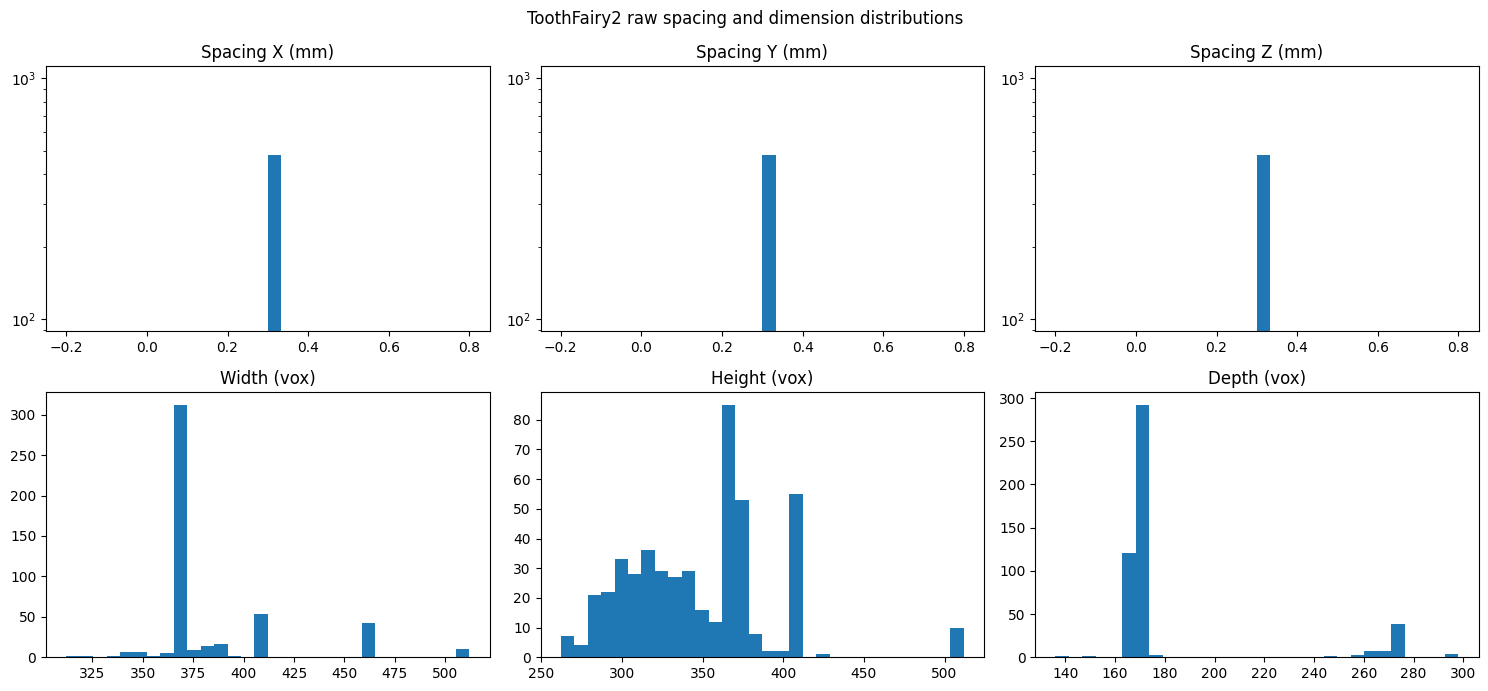

TF2 sample scan: 100%|██████████| 50/50 [06:39<00:00,  7.98s/it]



Distinct source labels in sample:
 source_label  voxel_count  mapped_to
            0   1208498554          0
            1     77476563          2
            2      3776828          2
            3       716709          3
            4       745940          3
            5       376826          0
            6       279122          0
            7     27212186          0
            8       321053          0
            9       809200          0
           10        45830          0
           11       174637          1
           12       123809          1
           13       207253          1
           14       234522          1
           15       279311          1
           16       638436          1
           17       581241          1
           18       178088          1
           21       187058          1
           22       120269          1
           23       217618          1
           24       247105          1
           25       276911          1
           26  

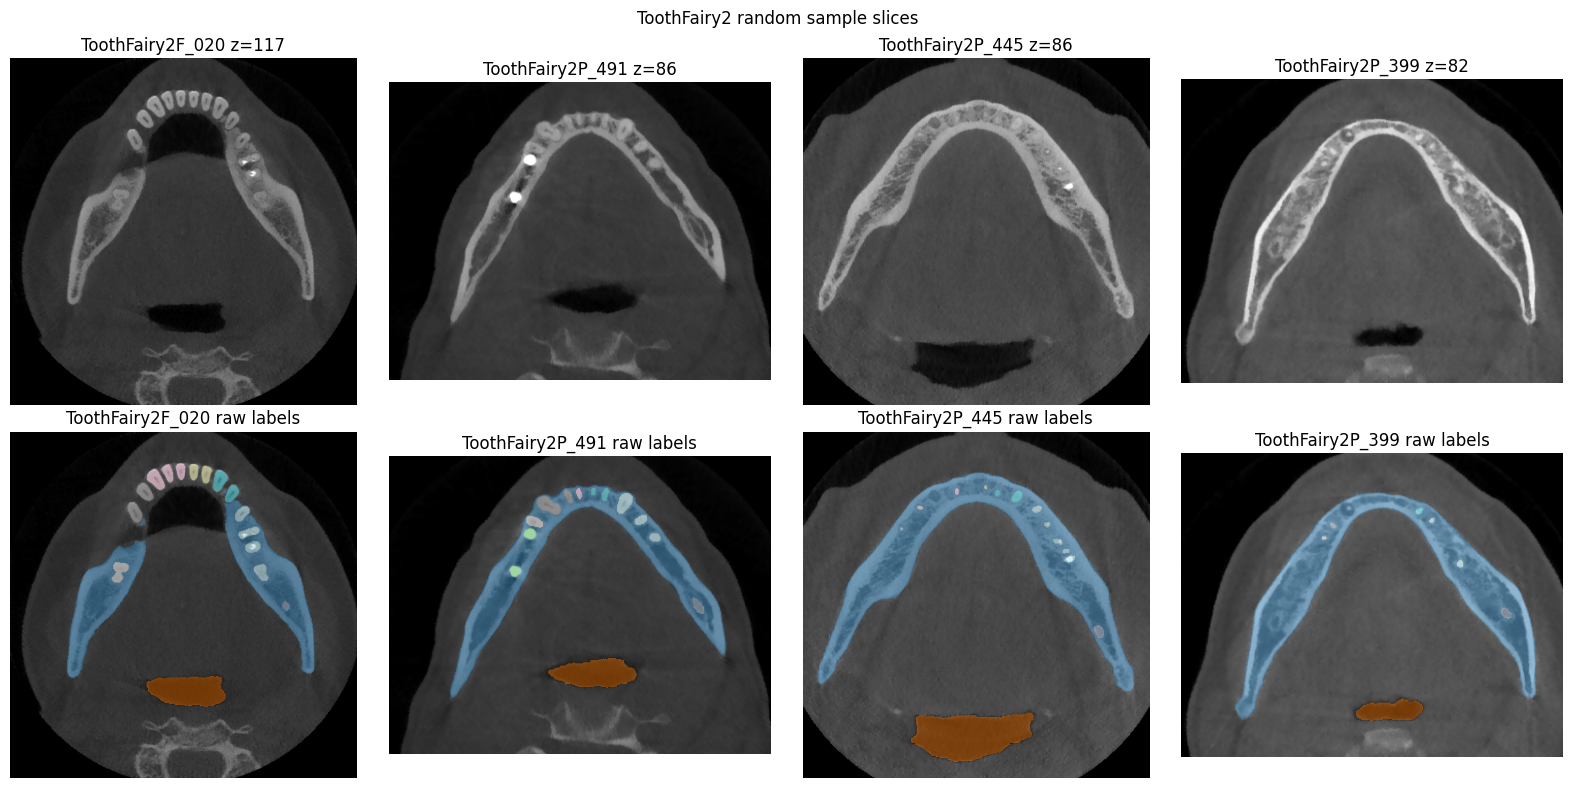

In [ ]:
import matplotlib.pyplot as plt
import tqdm

def get_pixel_type_from_reader(reader: sitk.ImageFileReader) -> str:
    try:
        return sitk.GetPixelIDValueAsString(reader.GetPixelID())
    except Exception:
        return str(reader.GetPixelID())


def eda_toothfairy2(sample_n: int = 50, force: bool = False) -> Dict[str, pd.DataFrame]:
    images_dir = TOOTHFAIRY_RAW / 'imagesTr'
    labels_dir = TOOTHFAIRY_RAW / 'labelsTr'

    if not images_dir.exists():
        raise FileNotFoundError(images_dir)

    if not labels_dir.exists():
        raise FileNotFoundError(labels_dir)

    LOG_DIR.mkdir(parents=True, exist_ok=True)

    image_files = sorted(images_dir.glob('*_0000.mha'))

    print(f"TF2 raw images: {len(image_files)}")

    headers_csv = LOG_DIR / 'tf2_eda_headers.csv'
    labels_csv = LOG_DIR / 'tf2_eda_label_counts.csv'
    intensity_csv = LOG_DIR / 'tf2_eda_intensity.csv'

    required_header_cols = ['case_id', 'W', 'H', 'D', 'sx', 'sy', 'sz', 'voxels', 'file_mb', 'pixel_type']

    if headers_csv.exists() and not force:
        header_df = pd.read_csv(headers_csv)
        if len(header_df) == 0 or not set(required_header_cols).issubset(header_df.columns):
            print("Cached header scan is empty/incomplete; recomputing.")
            force = True
        else:
            print(f"Loaded cached header scan: {len(header_df)} rows")

    if force or not headers_csv.exists():
        rows = []
        reader = sitk.ImageFileReader()

        for img_path in tqdm.tqdm(image_files, desc='TF2 headers'):
            case_id = img_path.stem.replace('_0000', '')

            try:
                reader.SetFileName(str(img_path))
                reader.ReadImageInformation()

                size = reader.GetSize()
                spacing = reader.GetSpacing()

                rows.append({
                    'case_id': case_id,
                    'W': size[0],
                    'H': size[1],
                    'D': size[2],
                    'sx': spacing[0],
                    'sy': spacing[1],
                    'sz': spacing[2],
                    'voxels': size[0] * size[1] * size[2],
                    'file_mb': img_path.stat().st_size / 1024 ** 2,
                    'pixel_type': get_pixel_type_from_reader(reader),
                })
            except Exception as e:
                log.warning(f"{case_id}: header read failed ({e})")

        header_df = pd.DataFrame(rows)
        header_df.to_csv(headers_csv, index=False)

    if len(header_df) == 0:
        raise RuntimeError("TF2 header scan produced 0 rows. Check imagesTr path and file readability.")

    print("\nRaw header summary:")
    print(header_df[['W', 'H', 'D', 'sx', 'sy', 'sz', 'voxels', 'file_mb']].describe().round(3))

    aniso = (
        header_df[['sx', 'sy', 'sz']].max(axis=1)
        / header_df[['sx', 'sy', 'sz']].min(axis=1)
    )

    print(
        f"\nAnisotropy ratio: mean={aniso.mean():.3f}, "
        f"max={aniso.max():.3f}"
    )
    print(f"Pixel types: {header_df['pixel_type'].value_counts().to_dict()}")

    fig, axes = plt.subplots(2, 3, figsize=(15, 7))

    for ax, col, title in zip(
        axes[0],
        ['sx', 'sy', 'sz'],
        ['Spacing X (mm)', 'Spacing Y (mm)', 'Spacing Z (mm)'],
    ):
        ax.hist(header_df[col], bins=30)
        ax.set_title(title)
        ax.set_yscale('log')

    for ax, col, title in zip(
        axes[1],
        ['W', 'H', 'D'],
        ['Width (vox)', 'Height (vox)', 'Depth (vox)'],
    ):
        ax.hist(header_df[col], bins=30)
        ax.set_title(title)

    plt.suptitle('ToothFairy2 raw spacing and dimension distributions')
    plt.tight_layout()
    plt.show()

    if labels_csv.exists() and intensity_csv.exists() and not force:
        label_counts_df = pd.read_csv(labels_csv)
        intensity_df = pd.read_csv(intensity_csv)

        if len(label_counts_df) == 0:
            print("\nCached label scan is empty; recomputing.")
            force = True
        else:
            print("\nLoaded cached label and intensity scans")

    if force or not labels_csv.exists() or not intensity_csv.exists():
        sample_ids = header_df.sample(
            min(sample_n, len(header_df)),
            random_state=SEED,
        )['case_id']

        label_counter: Dict[int, int] = {}
        intensity_rows = []

        for case_id in tqdm.tqdm(sample_ids, desc='TF2 sample scan'):
            lbl_path = labels_dir / f'{case_id}.mha'
            img_path = images_dir / f'{case_id}_0000.mha'

            if not lbl_path.exists() or not img_path.exists():
                continue

            try:
                label = sitk.GetArrayFromImage(sitk.ReadImage(str(lbl_path))).ravel()
                values, counts = np.unique(label, return_counts=True)

                for value, count in zip(values.tolist(), counts.tolist()):
                    label_counter[int(value)] = label_counter.get(int(value), 0) + int(count)

                image = sitk.GetArrayFromImage(sitk.ReadImage(str(img_path)))

                intensity_rows.append({
                    'case_id': case_id,
                    'min': float(image.min()),
                    'max': float(image.max()),
                    'mean': float(image.mean()),
                    'std': float(image.std()),
                    'p1': float(np.percentile(image, 1)),
                    'p99': float(np.percentile(image, 99)),
                })

                del label, image
                gc.collect()
            except Exception as e:
                log.warning(f"{case_id}: full read failed ({e})")

        label_counts_df = pd.DataFrame(
            sorted(label_counter.items()),
            columns=['source_label', 'voxel_count'],
        )

        label_counts_df['mapped_to'] = label_counts_df['source_label'].map(
            lambda x: TF2_LABEL_MAP.get(int(x), 'BACKGROUND (unmapped)')
        )

        intensity_df = pd.DataFrame(intensity_rows)

        label_counts_df.to_csv(labels_csv, index=False)
        intensity_df.to_csv(intensity_csv, index=False)

    print("\nDistinct source labels in sample:")
    print(label_counts_df.to_string(index=False))

    unmapped = label_counts_df[
        (label_counts_df['source_label'] != 0)
        & (label_counts_df['mapped_to'].astype(str) == 'BACKGROUND (unmapped)')
    ]

    if len(unmapped):
        print(f"\n⚠ {len(unmapped)} source label(s) seen but not in TF2_LABEL_MAP:")
        print(unmapped.to_string(index=False))
    else:
        print("\n✓ All non-zero source labels in sample are mapped.")

    def target_name(value: Any) -> str:
        try:
            return TF2_CLASS_NAMES[int(value)]
        except (ValueError, TypeError, IndexError):
            return 'background'

    by_target = label_counts_df.copy()
    by_target['target_class'] = by_target['mapped_to'].map(target_name)

    target_counts = by_target.groupby('target_class')['voxel_count'].sum()
    proportions = (target_counts / target_counts.sum() * 100).round(3)

    print("\nVoxel proportion per target class:")
    for cls, pct in proportions.items():
        print(f"  {cls:12s}: {pct:>7.3f}%")

    if len(intensity_df):
        print(f"\nRaw image intensity stats ({len(intensity_df)} cases):")
        print(intensity_df[['min', 'max', 'mean', 'std', 'p1', 'p99']].describe().round(2))

    sample_ids = header_df.sample(min(4, len(header_df)), random_state=SEED + 1)['case_id'].tolist()

    fig, axes = plt.subplots(2, len(sample_ids), figsize=(4 * len(sample_ids), 8))

    if len(sample_ids) == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for i, case_id in enumerate(sample_ids):
        try:
            image = sitk.GetArrayFromImage(
                sitk.ReadImage(str(images_dir / f'{case_id}_0000.mha'))
            )
            label = sitk.GetArrayFromImage(
                sitk.ReadImage(str(labels_dir / f'{case_id}.mha'))
            )

            foreground = np.argwhere(label > 0)
            z = int(np.median(foreground[:, 0])) if len(foreground) else image.shape[0] // 2

            axes[0, i].imshow(image[z], cmap='gray')
            axes[0, i].set_title(f'{case_id} z={z}')
            axes[0, i].axis('off')

            axes[1, i].imshow(image[z], cmap='gray')
            axes[1, i].imshow(
                np.ma.masked_where(label[z] == 0, label[z]),
                alpha=0.45,
                cmap='tab20',
            )
            axes[1, i].set_title(f'{case_id} raw labels')
            axes[1, i].axis('off')

            del image, label
            gc.collect()
        except Exception as e:
            log.warning(f"{case_id}: slice plot failed ({e})")

    plt.suptitle('ToothFairy2 random sample slices')
    plt.tight_layout()
    plt.show()

    return {
        'headers': header_df,
        'label_counts': label_counts_df,
        'intensity_stats': intensity_df,
    }


tf2_eda = eda_toothfairy2(sample_n=50, force=True)

## 8. ToothFairy2 PREPROCESSING PIPELINE


In [ ]:
def _preproc_config_hash(cfg: PreprocConfig) -> str:
    """Stable hash of the active preprocessing config, written into the manifest."""
    return hashlib.md5(json.dumps(asdict(cfg), sort_keys=True, default=str).encode()).hexdigest()[:12]


def preprocess_toothfairy2(cfg: PreprocConfig = PREPROC) -> pd.DataFrame:
    images_dir   = TOOTHFAIRY_RAW / 'imagesTr'
    labels_dir   = TOOTHFAIRY_RAW / 'labelsTr'
    out_img_dir  = TF2_PREPROC / 'images'
    out_lbl_dir  = TF2_PREPROC / 'labels'
    out_lbl_dir.mkdir(exist_ok=True, parents=True)

    image_files = sorted(images_dir.glob('*_0000.mha'))
    log.info(f"Found {len(image_files)} TF2 image volumes")

    cfg_hash = _preproc_config_hash(cfg)
    manifest: List[dict] = []
    failed: List[Tuple[str, str]] = []

    for img_path in tqdm.tqdm(image_files, desc='Preprocessing TF2'):
        case_id = img_path.stem.replace('_0000', '')
        lbl_path = labels_dir / f'{case_id}.mha'
        out_img        = out_img_dir / f'{case_id}.npy'
        out_lbl_4class = out_lbl_dir / f'{case_id}_4class.npy'
        out_lbl_fdi    = out_lbl_dir / f'{case_id}_fdi.npy'
        out_lbl_group  = out_lbl_dir / f'{case_id}_group.npy'

        # Idempotent skip — all four outputs must exist and load
        if cfg.skip_existing and all(p.exists() for p in (out_img, out_lbl_4class, out_lbl_fdi, out_lbl_group)):
            try:
                img_shape = tuple(np.load(out_img, mmap_mode='r').shape)
                lbl_shape = tuple(np.load(out_lbl_4class, mmap_mode='r').shape)
                if img_shape != lbl_shape:
                    raise ValueError(f"cached shapes disagree: {img_shape} vs {lbl_shape}")
                # Recompute the same fields the fresh branch writes, so a partial
                # (skip_existing) re-run yields a manifest with identical columns.
                lbl_4c = np.asarray(np.load(out_lbl_4class, mmap_mode='r'))
                lbl_fc = np.asarray(np.load(out_lbl_fdi, mmap_mode='r'))
                fg = np.argwhere(lbl_4c > 0)
                present_fdi = sorted(int(IDX_TO_FDI[i]) for i in np.unique(lbl_fc) if i > 0)
                manifest.append({
                    'case_id': case_id,
                    'img': str(out_img),
                    'lbl_4class': str(out_lbl_4class),
                    'lbl_fdi':    str(out_lbl_fdi),
                    'lbl_group':  str(out_lbl_group),
                    'shape_d': img_shape[0], 'shape_h': img_shape[1], 'shape_w': img_shape[2],
                    'fg_z_min': int(fg[:,0].min()) if len(fg) else 0,
                    'fg_z_max': int(fg[:,0].max()) if len(fg) else 0,
                    'fg_y_min': int(fg[:,1].min()) if len(fg) else 0,
                    'fg_y_max': int(fg[:,1].max()) if len(fg) else 0,
                    'fg_x_min': int(fg[:,2].min()) if len(fg) else 0,
                    'fg_x_max': int(fg[:,2].max()) if len(fg) else 0,
                    'n_teeth_present': len(present_fdi),
                    'present_fdi': ','.join(str(f) for f in present_fdi),
                    'img_md5': md5_of_file(out_img),
                    'preproc_config_hash': cfg_hash,
                    'cached': True,
                })
                del lbl_4c, lbl_fc, fg
                gc.collect()
                continue
            except Exception as e:
                log.warning(f"{case_id}: cached files unreadable ({e}); reprocessing")

        if not lbl_path.exists():
            failed.append((case_id, 'missing_label'))
            continue

        try:
            img_d = load_volume(img_path)
            lbl_d = load_volume(lbl_path)
            if img_d['shape'] != lbl_d['shape']:
                raise ValueError(f"image {img_d['shape']} != label {lbl_d['shape']}")

            img_res = resample_volume(
                img_d['array'], img_d['spacing'], cfg.target_spacing,
                is_label=False, src_origin=img_d['origin'], src_direction=img_d['direction'],
            )
            lbl_res = resample_volume(
                lbl_d['array'], lbl_d['spacing'], cfg.target_spacing,
                is_label=True,  src_origin=lbl_d['origin'], src_direction=lbl_d['direction'],
            )
            if img_res.shape != lbl_res.shape:
                raise ValueError(f"resampled shapes: img {img_res.shape} vs lbl {lbl_res.shape}")

            lbl_4class = remap_labels(lbl_res, TF2_LUT).astype(cfg.save_dtype_label)
            lbl_fdi    = remap_labels(lbl_res, TF2_LUT_FDI).astype(cfg.save_dtype_label)
            lbl_group  = remap_labels(lbl_res, TF2_LUT_GROUP).astype(cfg.save_dtype_label)

            if len(np.unique(lbl_4class)) < 2:
                raise ValueError("remapped 4-class label has no foreground voxels")

            img_norm = normalize_intensity(
                img_res,
                use_percentile_clip=cfg.use_percentile_clip,
                fixed_clip_range=cfg.fixed_clip_range,
                clip_percentiles=cfg.clip_percentiles,
            )

            np.save(out_img,        img_norm.astype(cfg.save_dtype_image))
            np.save(out_lbl_4class, lbl_4class)
            np.save(out_lbl_fdi,    lbl_fdi)
            np.save(out_lbl_group,  lbl_group)

            fg = np.argwhere(lbl_4class > 0)
            present_fdi = sorted(int(IDX_TO_FDI[i]) for i in np.unique(lbl_fdi) if i > 0)

            manifest.append({
                'case_id': case_id,
                'img': str(out_img),
                'lbl_4class': str(out_lbl_4class),
                'lbl_fdi':    str(out_lbl_fdi),
                'lbl_group':  str(out_lbl_group),
                'shape_d': img_norm.shape[0],
                'shape_h': img_norm.shape[1],
                'shape_w': img_norm.shape[2],
                'fg_z_min': int(fg[:,0].min()), 'fg_z_max': int(fg[:,0].max()),
                'fg_y_min': int(fg[:,1].min()), 'fg_y_max': int(fg[:,1].max()),
                'fg_x_min': int(fg[:,2].min()), 'fg_x_max': int(fg[:,2].max()),
                'n_teeth_present': len(present_fdi),
                'present_fdi': ','.join(str(f) for f in present_fdi),
                'img_md5': md5_of_file(out_img),
                'preproc_config_hash': cfg_hash,
                'cached': False,
            })

            del img_d, lbl_d, img_res, lbl_res, img_norm, lbl_4class, lbl_fdi, lbl_group
            gc.collect()
        except Exception as e:
            failed.append((case_id, str(e)))
            log.error(f"{case_id}: {e}")

    manifest_df = pd.DataFrame(manifest)
    manifest_df.to_csv(TF2_PREPROC / 'manifest.csv', index=False)
    if failed:
        err_path = LOG_DIR / 'tf2_preproc_errors.txt'
        with open(err_path, 'w') as f:
            for cid, reason in failed:
                f.write(f"{cid}\t{reason}\n")
        log.warning(f"TF2: {len(failed)} cases failed (see {err_path})")
    log.info(f"TF2 manifest: {len(manifest_df)} cases (skipped {len(failed)})")
    return manifest_df


tf2_manifest = preprocess_toothfairy2(PREPROC)
print()
print(tf2_manifest.head())
print("\nShape stats (D, H, W):")
print(tf2_manifest[['shape_d', 'shape_h', 'shape_w']].describe().round(1))

Preprocessing TF2: 100%|██████████| 480/480 [1:24:08<00:00, 10.52s/it]



            case_id                                                img  \
0  ToothFairy2F_001  /content/drive/MyDrive/Teeth_Segmentation_Clas...   
1  ToothFairy2F_002  /content/drive/MyDrive/Teeth_Segmentation_Clas...   
2  ToothFairy2F_003  /content/drive/MyDrive/Teeth_Segmentation_Clas...   
3  ToothFairy2F_004  /content/drive/MyDrive/Teeth_Segmentation_Clas...   
4  ToothFairy2F_005  /content/drive/MyDrive/Teeth_Segmentation_Clas...   

                                          lbl_4class  \
0  /content/drive/MyDrive/Teeth_Segmentation_Clas...   
1  /content/drive/MyDrive/Teeth_Segmentation_Clas...   
2  /content/drive/MyDrive/Teeth_Segmentation_Clas...   
3  /content/drive/MyDrive/Teeth_Segmentation_Clas...   
4  /content/drive/MyDrive/Teeth_Segmentation_Clas...   

                                             lbl_fdi  \
0  /content/drive/MyDrive/Teeth_Segmentation_Clas...   
1  /content/drive/MyDrive/Teeth_Segmentation_Clas...   
2  /content/drive/MyDrive/Teeth_Segmentation_Clas

In [ ]:
# Sanity Checks
image_paths = {p.stem: p for p in (TF2_PREPROC / 'images').glob('*.npy')}
label_paths = {p.stem.replace('_4class', ''): p
               for p in (TF2_PREPROC / 'labels').glob('*_4class.npy')}

expected_case_ids = sorted([
    p.stem.replace('_0000', '')
    for p in (TOOTHFAIRY_RAW / 'imagesTr').glob('*_0000.mha')
])

print(f"Expected cases:       {len(expected_case_ids)}")
print(f"TF2 image npy files:  {len(image_paths)}")
print(f"TF2 label npy files:  {len(label_paths)}")

bad_cases = []

for case_id in tqdm.tqdm(expected_case_ids, desc='Verifying TF2 outputs'):
    img_path = image_paths.get(case_id)
    lbl_path = label_paths.get(case_id)

    if img_path is None:
        bad_cases.append((case_id, 'missing_image'))
        continue

    if lbl_path is None:
        bad_cases.append((case_id, 'missing_label'))
        continue

    try:
        img = np.load(img_path, mmap_mode='r')
        lbl = np.load(lbl_path, mmap_mode='r')

        if img.shape != lbl.shape:
            bad_cases.append((case_id, 'shape_mismatch', img.shape, lbl.shape))

        if img.dtype != np.float32:
            bad_cases.append((case_id, 'bad_image_dtype', str(img.dtype)))

        if lbl.dtype != np.uint8:
            bad_cases.append((case_id, 'bad_label_dtype', str(lbl.dtype)))

        z_indices = sorted(set([
            0,
            lbl.shape[0] // 4,
            lbl.shape[0] // 2,
            3 * lbl.shape[0] // 4,
            lbl.shape[0] - 1,
        ]))

        for z in z_indices:
            values = np.unique(lbl[z])
            if not set(values.tolist()).issubset({0, 1, 2, 3}):
                bad_cases.append((case_id, f'bad_label_values_slice_{z}', values.tolist()))
                break

    except Exception as e:
        bad_cases.append((case_id, 'load_failed', str(e)))

print(f"\nBad cases: {len(bad_cases)}")

if bad_cases:
    for item in bad_cases[:30]:
        print(item)
else:
    print("✓ TF2 Verification Passed.")

Expected cases:       480
TF2 image npy files:  480
TF2 label npy files:  480


Verifying TF2 outputs: 100%|██████████| 480/480 [03:34<00:00,  2.24it/s]


Bad cases: 0
✓ TF2 Verification Passed.
